In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import string

In [3]:
# import south park data
df_sp = pd.read_csv("sp_toxdect_v6.csv")
df_sp = df_sp.drop(columns= "Unnamed: 0")
df_fg = pd.read_csv("fg_toxdect.csv")

for i, df in enumerate([df_sp, df_fg]):
    df = df[df["Episode"] != "Episode"] # make sure episode is a number
    df = df[df["Season"] != "Season"]  # Keep only numeric season values

    df = df[~df['Line'].isna()]  # Remove blank lines

    # Assign offensiveness class
    df["class"] = np.where(df["prob"] > 90, 1, 0)

    # Ensure season and episode are integer types
    df["Episode"] = df["Episode"].astype(int)
    df["Season"] = df["Season"].astype(int)

    # Remove lines that are <= 3 words
    df["split_line"] = df["Line"].str.split().apply(lambda x: [word for word in x if word.strip() != ""])
    df["line_len"] = df["split_line"].apply(len)
    df = df[df["line_len"] > 3]

    # Reassign the modified DataFrame back
    if i == 0:
        df_sp = df
    else:
        df_fg = df

print(df_sp["Season"].unique())

[10 11 12 13 14 15 16 17 18  1  2  3  4  5  6  7  8  9]


/var/folders/y3/9kz6d9vd0x33ydn26_b3sfs40000gn/T/ipykernel_95726/3362829064.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  episode_means = df.groupby(['Season', 'Episode'])['prob'].mean().reset_index()


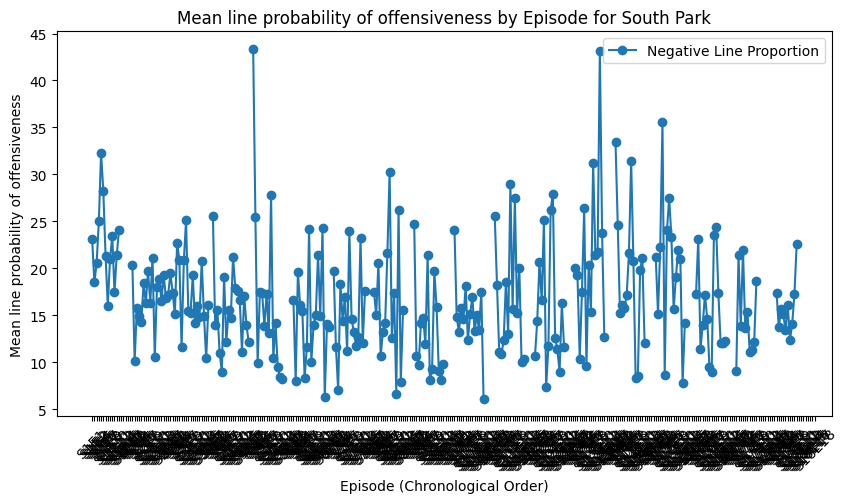

/var/folders/y3/9kz6d9vd0x33ydn26_b3sfs40000gn/T/ipykernel_95726/3362829064.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  episode_means = df.groupby(['Season', 'Episode'])['prob'].mean().reset_index()


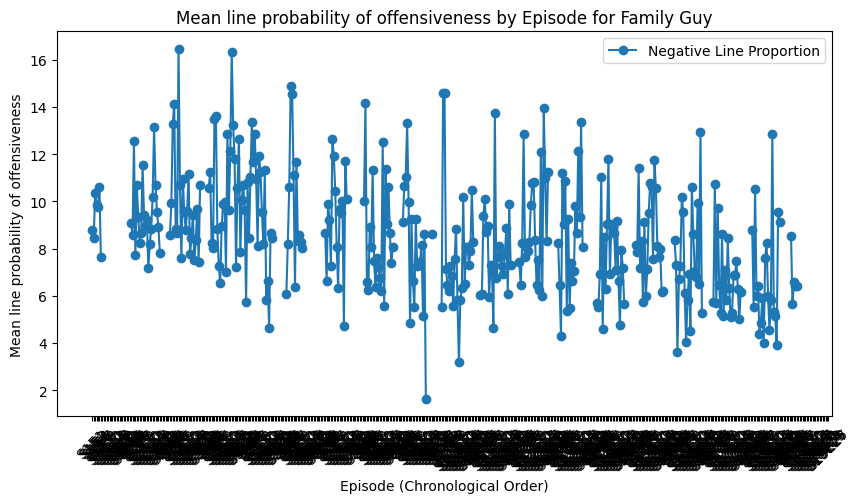

In [74]:
# plot episode means for both
df_types = {"df_sp": "South Park", "df_fg": "Family Guy"}
for df in [df_sp, df_fg]:

    episode_means = df.groupby(['Season', 'Episode'])['prob'].mean().reset_index()
    episode_means = episode_means.sort_values(by=['Season', 'Episode'])
    # Create a continuous x-axis (indexing episodes chronologically)
    episode_means['x'] = range(len(episode_means))  # Create a sequential x-axis

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(episode_means['x'], episode_means['prob'], marker='o', linestyle='-', label="Negative Line Proportion")

    # Customize X-axis labels
    plt.xticks(episode_means['x'], labels=[f"S{s}E{e}" for s, e in zip(episode_means['Season'], episode_means['Episode'])], rotation=45)

    # Labels and Title
    plt.xlabel("Episode (Chronological Order)")
    plt.ylabel("Mean line probability of offensiveness")
    if df.equals(df_sp):
        plt.title(f"Mean line probability of offensiveness by Episode for South Park")
    if df.equals(df_fg):
        plt.title(f"Mean line probability of offensiveness by Episode for Family Guy")
    plt.legend()

    plt.show()

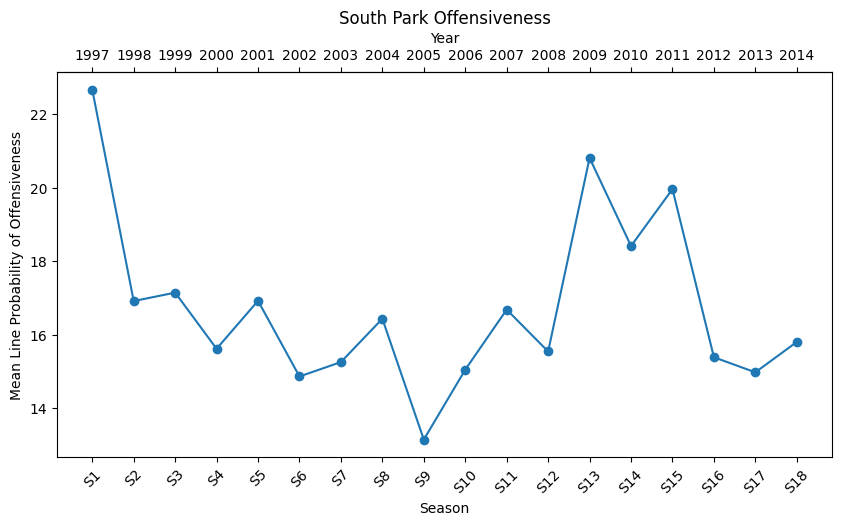

In [4]:
# plot season means for south park
sp_season_means = df_sp.groupby('Season')['prob'].mean().reset_index()
sp_season_means = sp_season_means.sort_values(by=['Season'])
sp_season_means["year"] = list(range(1997, 2015))
sp_season_means['x'] = range(len(sp_season_means))

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(sp_season_means['x'], sp_season_means['prob'], marker='o', linestyle='-')
ax1.set_xticks(sp_season_means['x'])
ax1.set_xticklabels([f"S{s}" for s in sp_season_means['Season']], rotation=45)
ax1.set_xlabel("Season")
ax1.set_ylabel("Mean Line Probability of Offensiveness")
ax1.set_title("South Park Offensiveness")

ax2 = ax1.secondary_xaxis('top')
ax2.set_xticks(sp_season_means['x'])
ax2.set_xticklabels([str(y) for y in sp_season_means["year"]])
ax2.set_xlabel("Year")

plt.show()

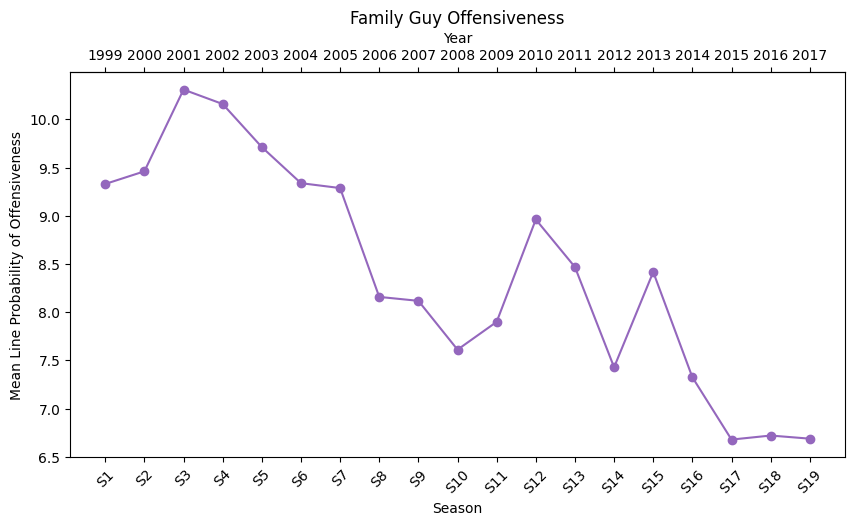

In [6]:
# plot season means for family guy
fg_season_means = df_fg.groupby('Season')['prob'].mean().reset_index()
fg_season_means = fg_season_means.sort_values(by=['Season'])
fg_season_means["year"] = list(range(1999, 2018))
fg_season_means['x'] = range(len(fg_season_means))

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(fg_season_means['x'], fg_season_means['prob'], marker='o', linestyle='-', color='tab:purple')
ax1.set_xticks(fg_season_means['x'])
ax1.set_xticklabels([f"S{s}" for s in fg_season_means['Season']], rotation=45)
ax1.set_xlabel("Season")
ax1.set_ylabel("Mean Line Probability of Offensiveness")
ax1.set_title("Family Guy Offensiveness")

ax2 = ax1.secondary_xaxis('top')
ax2.set_xticks(fg_season_means['x'])
ax2.set_xticklabels([str(y) for y in fg_season_means["year"]])
ax2.set_xlabel("Year")

plt.show()

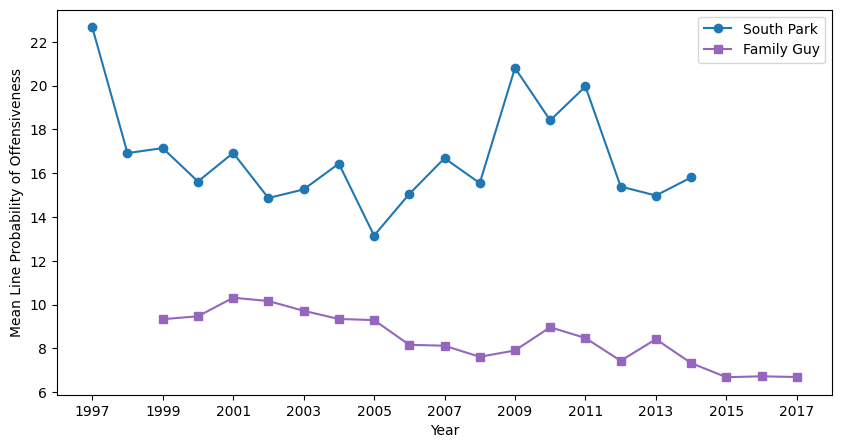

In [7]:
# plot both shows by year
plt.figure(figsize=(10, 5))
plt.plot(sp_season_means["year"], sp_season_means["prob"], marker='o', linestyle='-', label="South Park")
plt.plot(fg_season_means["year"], fg_season_means["prob"], marker='s', linestyle='-', label="Family Guy", color="tab:purple")

# Labels, Title, and Legend
plt.xlabel("Year")
plt.xticks(range(1997, 2018, 2))
plt.ylabel("Mean Line Probability of Offensiveness")
plt.legend()
plt.show()

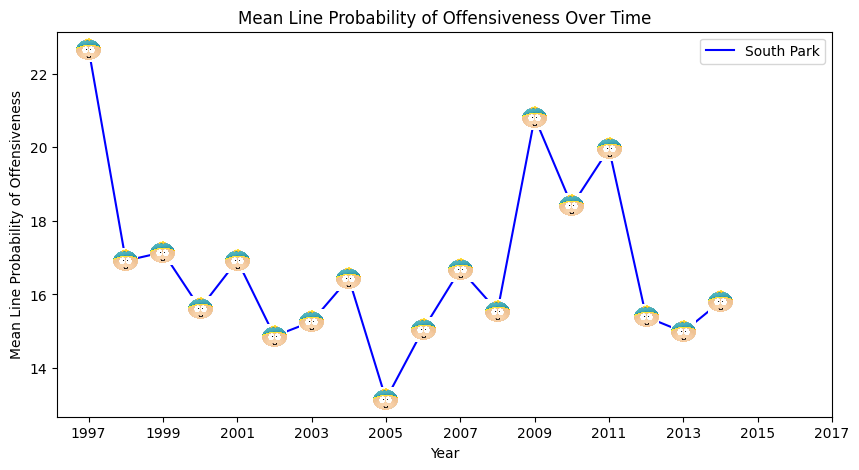

In [70]:
# messing around with the graphs
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Load custom marker images
sp_marker = mpimg.imread("sp_marker.jpg") 
fg_marker = mpimg.imread("fg_marker.png") 

# Function to place image at each data point
def add_custom_markers(ax, x_values, y_values, image, zoom):
    for x, y in zip(x_values, y_values):
        im = OffsetImage(image, zoom=zoom)  # Adjust zoom as needed
        ab = AnnotationBbox(im, (x, y), frameon=False)
        ax.add_artist(ab)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 5))

# Plot lines (without markers)
ax.plot(sp_season_means["year"], sp_season_means["prob"], linestyle='-', label="South Park", color='blue')
#ax.plot(fg_season_means["year"], fg_season_means["prob"], linestyle='-', label="Family Guy", color='red')

# Add custom markers
add_custom_markers(ax, sp_season_means["year"], sp_season_means["prob"], sp_marker, 0.08)
#add_custom_markers(ax, fg_season_means["year"], fg_season_means["prob"], fg_marker, 0.04)

# Customize x-axis ticks every 2 years
ax.set_xticks(range(1997, 2018, 2))

# Labels, Title, and Legend
ax.set_xlabel("Year")
ax.set_ylabel("Mean Line Probability of Offensiveness")
ax.set_title("Mean Line Probability of Offensiveness Over Time")
ax.legend()

plt.show()


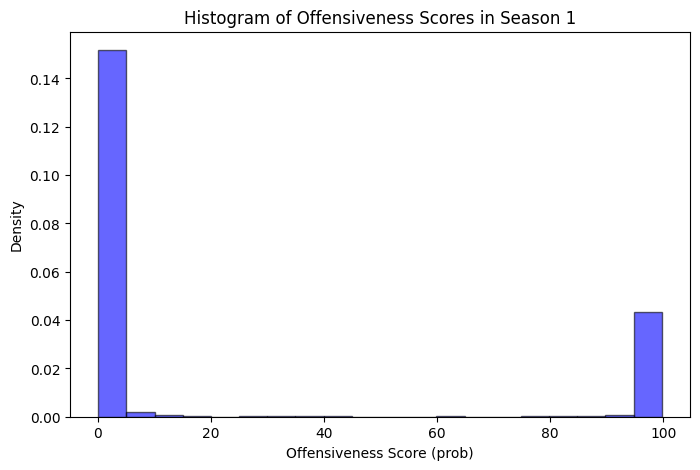

In [75]:
def plot_offensiveness_hist(df, season):
    season_data = df[df['Season'] == season]
    if season_data.empty:
        print(f"No data available for Season {season}.")
        return
    
    plt.figure(figsize=(8, 5))
    plt.hist(season_data['prob'], bins=20, density=True, alpha=0.6, color='blue', edgecolor='black')
    
    plt.xlabel("Offensiveness Score (prob)")
    plt.ylabel("Density")
    plt.title(f"Histogram of Offensiveness Scores in Season {season}")
    
    plt.show()
plot_offensiveness_hist(df_sp, 1)
# none of the distributions are normal
# if restricted to only looking at lines about 80 the distrib is more normal

In [ ]:
# messing around with the plot

In [76]:
#ANOVA test - data doesn't meet this assumption
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg

# season needs to be categorical for this
df_sp['Season'] = df_sp['Season'].astype('category')
df_fg['Season'] = df_fg['Season'].astype('category')

# check homogeneity of variance
pg.homoscedasticity(data=df, 
                    dv="prob", 
                    group="Season").round(2)
# okay rip not homogenous: use welch's anova

#check normality
model = ols("prob ~ Season", data=df).fit()
res = model.resid
pg.normality(res)

# soooo this is not normal either. can't use anova at all

# run non-parametric Kruskal-Wallis test
pg.kruskal(data=df_sp, 
        dv='prob', 
        between='Season')
# p-val from this is significant
# pg.kruskal(data=df_fg, 
#         dv='prob', 
#         between='Season')


/opt/homebrew/lib/python3.11/site-packages/pingouin/distribution.py:230: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 123124.
  stats = numdata.apply(lambda x: func(x.dropna()), result_type="expand", axis=0).T


,Source,ddof1,H,p-unc
Kruskal,Season,17,196.355764,1.544975e-32


In [53]:
# Fisher tests for class differences btw sequential seasons
from scipy.stats import fisher_exact

def fisher_test(df, season1, season2):
    df.loc[df['class'].astype(int), 'class']
    df_filtered = df[df['Season'].isin([season1, season2])]
    table = (
        df_filtered.groupby('Season')['class']
        .value_counts()
        .unstack(fill_value=0)
        .reindex([season1, season2], fill_value=0)  # Ensure only two rows
    )   
    oddsratio, p = fisher_exact(table)

    return oddsratio, p, table

pvals_sp = pd.DataFrame({"s1": [], "s2": [], "pval": []})

# get fisher tests for every consecutive season pair
for i in range (1, len(df_sp["Season"].unique())):
    odds_ratio, p_value, table = fisher_test(df_sp, i, i+1)
    pvals_sp.loc[len(pvals_sp)] = [i, i+1, p_value]

# apply holm correction
pvals_sp = pvals_sp.sort_values(by = "pval", ascending = False)
pvals_sp["rank"] = range(1, len(pvals_sp)+1)
pvals_sp["holm_pval"] = pvals_sp["pval"] * pvals_sp["rank"]
pvals_sp["significant"] = pvals_sp["holm_pval"]< 0.05

# repeat analysis for family guy
pvals_fg = pd.DataFrame({"s1": [], "s2": [], "pval": []})

# get fisher tests for every consecutive season pair
for i in range (1, len(df_fg["Season"].unique())):
    odds_ratio, p_value, table = fisher_test(df_fg, i, i+1)
    pvals_fg.loc[len(pvals_fg)] = [i, i+1, p_value]

# apply holm correction
pvals_fg = pvals_fg.sort_values(by = "pval", ascending = False)
pvals_fg["rank"] = range(1, len(pvals_fg)+1)
pvals_fg["holm_pval"] = pvals_fg["pval"] * pvals_fg["rank"]
pvals_fg["significant"] = pvals_fg["holm_pval"]< 0.05

# sp significant difference at 0.05: 8&9, 15&16, 12&13, 1&2
# fg significant difference at 0.05: None


/var/folders/y3/9kz6d9vd0x33ydn26_b3sfs40000gn/T/ipykernel_95726/2352183387.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby('Season')['class']
/var/folders/y3/9kz6d9vd0x33ydn26_b3sfs40000gn/T/ipykernel_95726/2352183387.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby('Season')['class']
/var/folders/y3/9kz6d9vd0x33ydn26_b3sfs40000gn/T/ipykernel_95726/2352183387.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

,s1,s2,pval,rank,holm_pval,significant
17,18.0,19.0,1.000000,1,1.000000,False
5,6.0,7.0,0.941975,2,1.883949,False
2,3.0,4.0,0.896435,3,2.689305,False
0,1.0,2.0,0.789323,4,3.157292,False
7,8.0,9.0,0.776202,5,3.881010,False
16,17.0,18.0,0.684873,6,4.109240,False
4,5.0,6.0,0.502976,7,3.520833,False
11,12.0,13.0,0.452061,8,3.616490,False
9,10.0,11.0,0.426933,9,3.842399,False
3,4.0,5.0,0.410680,10,4.106801,False
